In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

from imblearn.over_sampling import SMOTE

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
df = pd.read_csv("cleaned_data.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.2+ KB


In [5]:
df.shape

(1337, 7)

In [7]:
y_reg = df["charges"]

In [8]:
y_clf = (df["charges"] > df["charges"].median()).astype(int)

In [9]:
X = df.drop("charges", axis=1)

In [10]:
print(X.head())

print(y_reg.head())

print(y_clf.head())

   age     sex     bmi  children smoker     region
0   19  female  27.900         0    yes  southwest
1   18    male  33.770         1     no  southeast
2   28    male  33.000         3     no  southeast
3   33    male  22.705         0     no  northwest
4   32    male  28.880         0     no  northwest
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64
0    1
1    0
2    0
3    1
4    0
Name: charges, dtype: int64


In [12]:
# Task 2: Encoding Categorical Variables

In [14]:
# Find categorical columns
categorical_columns = X.select_dtypes(include=["object", "category"]).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['sex', 'smoker', 'region'], dtype='object')


In [17]:
print(X.columns)

Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')


In [19]:
print(X.columns.tolist())

['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [20]:
# Task 3: Train-Test Split and Feature Scaling

In [22]:
# Regression train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [24]:
# Classification train-test split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

In [25]:
scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)

X_test_reg_scaled = scaler_reg.transform(X_test_reg)

In [26]:
scaler_clf = StandardScaler()

X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)

X_test_clf_scaled = scaler_clf.transform(X_test_clf)

In [28]:
print("Regression Training Shape :", X_train_reg_scaled.shape)
print("Regression Testing Shape  :", X_test_reg_scaled.shape)

print()

print("Classification Training Shape :", X_train_clf_scaled.shape)
print("Classification Testing Shape  :", X_test_clf_scaled.shape)

Regression Training Shape : (1069, 8)
Regression Testing Shape  : (268, 8)

Classification Training Shape : (1069, 8)
Classification Testing Shape  : (268, 8)


In [29]:
# Task 4: Linear Regression Model

In [30]:
# Create Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_reg_scaled, y_train_reg)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [31]:
# Predict on test data
y_pred_reg = linear_model.predict(X_test_reg_scaled)

In [32]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Squared Error (MSE): 35478020.675235614
R² Score: 0.8069287081198011


In [33]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

display(coefficients)

,Feature,Coefficient
0,age,3472.975553
1,bmi,1927.828251
2,children,636.501185
3,sex_male,-50.749675
4,smoker_yes,9234.342487
5,region_northwest,-168.944439
6,region_southeast,-371.780810
7,region_southwest,-284.610396


In [34]:
top3 = coefficients.copy()

top3["Absolute Coefficient"] = top3["Coefficient"].abs()

top3 = top3.sort_values(
    by="Absolute Coefficient",
    ascending=False
).head(3)

print("Top 3 Features with Largest Absolute Coefficients")

display(top3)

Top 3 Features with Largest Absolute Coefficients


,Feature,Coefficient,Absolute Coefficient
4,smoker_yes,9234.342487,9234.342487
0,age,3472.975553,3472.975553
1,bmi,1927.828251,1927.828251


In [35]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_reg_scaled, y_train_reg)

print("Ridge Regression Model Trained Successfully!")

Ridge Regression Model Trained Successfully!


In [36]:
ridge_pred = ridge_model.predict(X_test_reg_scaled)

In [37]:
ridge_mse = mean_squared_error(y_test_reg, ridge_pred)
ridge_r2 = r2_score(y_test_reg, ridge_pred)

print("Ridge MSE :", ridge_mse)
print("Ridge R² :", ridge_r2)

Ridge MSE : 35512474.82830553
Ridge R² : 0.8067412087126403


In [38]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "R² Score": [r2, ridge_r2]
})

display(comparison)

,Model,MSE,R² Score
0,Linear Regression,3.547802e+07,0.806929
1,Ridge Regression,3.551247e+07,0.806741


In [39]:
# Task 6: Class Imbalance Check

In [40]:
print("Training Class Distribution")

print(y_train_clf.value_counts())

Training Class Distribution
charges
0    535
1    534
Name: count, dtype: int64


In [41]:
class_percentage = y_train_clf.value_counts(normalize=True) * 100

print("Training Class Percentage")

print(class_percentage)

Training Class Percentage
charges
0    50.046773
1    49.953227
Name: proportion, dtype: float64


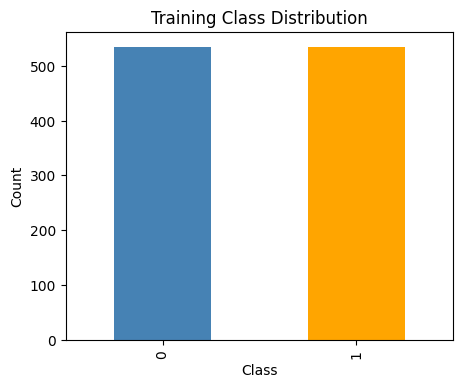

In [42]:
plt.figure(figsize=(5,4))

y_train_clf.value_counts().plot(kind="bar", color=["steelblue", "orange"])

plt.title("Training Class Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

In [43]:
# Task 7: Logistic Regression

In [44]:
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_clf_scaled,
    y_train_clf
)

print("Logistic Regression Trained Successfully!")

Logistic Regression Trained Successfully!


In [45]:
y_pred_clf = logistic_model.predict(X_test_clf_scaled)

y_prob = logistic_model.predict_proba(X_test_clf_scaled)[:,1]

In [46]:
cm = confusion_matrix(
    y_test_clf,
    y_pred_clf
)

print("Confusion Matrix")

print(cm)

Confusion Matrix
[[120  14]
 [ 11 123]]


In [47]:
print(classification_report(
    y_test_clf,
    y_pred_clf
))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       134
           1       0.90      0.92      0.91       134

    accuracy                           0.91       268
   macro avg       0.91      0.91      0.91       268
weighted avg       0.91      0.91      0.91       268



In [48]:
accuracy = logistic_model.score(
    X_test_clf_scaled,
    y_test_clf
)

print("Accuracy =", accuracy)

Accuracy = 0.9067164179104478


In [49]:
# Task 8: ROC Curve and AUC

In [50]:
# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test_clf, y_prob)

auc_score = roc_auc_score(y_test_clf, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.9528848295834261


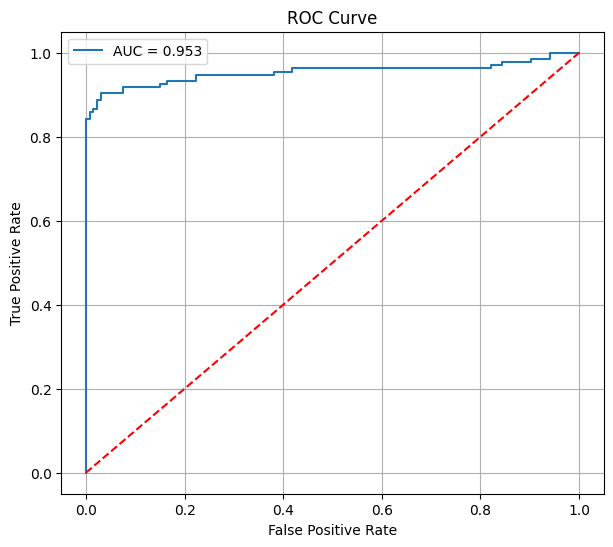

In [51]:
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0,1], [0,1], '--', color='red')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [52]:
# Task 9: Decision Threshold Sensitivity

In [53]:
threshold_results = []

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

for threshold in thresholds:

    predictions = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test_clf, predictions)

    recall = recall_score(y_test_clf, predictions)

    f1 = f1_score(y_test_clf, predictions)

    threshold_results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    threshold_results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

display(threshold_df)

,Threshold,Precision,Recall,F1 Score
0,0.3,0.779141,0.947761,0.855219
1,0.4,0.855172,0.925373,0.888889
2,0.5,0.897810,0.917910,0.907749
3,0.6,0.960317,0.902985,0.930769
4,0.7,1.000000,0.843284,0.914980


In [54]:
# Task 10: Logistic Regression Regularization

In [55]:
regularized_model = LogisticRegression(
    C=0.01,
    max_iter=1000
)

regularized_model.fit(
    X_train_clf_scaled,
    y_train_clf
)

regularized_prob = regularized_model.predict_proba(
    X_test_clf_scaled
)[:,1]

regularized_pred = regularized_model.predict(
    X_test_clf_scaled
)

precision_regularized = precision_score(
    y_test_clf,
    regularized_pred
)

recall_regularized = recall_score(
    y_test_clf,
    regularized_pred
)

auc_regularized = roc_auc_score(
    y_test_clf,
    regularized_prob
)

comparison = pd.DataFrame({

    "Model":[
        "Baseline (C=1.0)",
        "Regularized (C=0.01)"
    ],

    "Precision":[
        precision_score(y_test_clf, y_pred_clf),
        precision_regularized
    ],

    "Recall":[
        recall_score(y_test_clf, y_pred_clf),
        recall_regularized
    ],

    "AUC":[
        auc_score,
        auc_regularized
    ]

})

display(comparison)

,Model,Precision,Recall,AUC
0,Baseline (C=1.0),0.897810,0.917910,0.952885
1,Regularized (C=0.01),0.884058,0.910448,0.951103


In [57]:
# Task 11: Bootstrap Confidence Interval for AUC Difference
import numpy as np

bootstrap_differences = []

n_iterations = 500

for _ in range(n_iterations):

    indices = np.random.choice(
        len(y_test_clf),
        size=len(y_test_clf),
        replace=True
    )

    y_boot = y_test_clf.iloc[indices]

    baseline_boot = y_prob[indices]

    regularized_boot = regularized_prob[indices]

    auc_baseline = roc_auc_score(
        y_boot,
        baseline_boot
    )

    auc_regularized = roc_auc_score(
        y_boot,
        regularized_boot
    )

    bootstrap_differences.append(
        auc_baseline - auc_regularized
    )

bootstrap_differences = np.array(bootstrap_differences)

mean_difference = bootstrap_differences.mean()

lower = np.percentile(
    bootstrap_differences,
    2.5
)

upper = np.percentile(
    bootstrap_differences,
    97.5
)

print("Mean AUC Difference :", mean_difference)

print("95% Confidence Interval")

print("Lower :", lower)

print("Upper :", upper)

if lower > 0 or upper < 0:
    print("\nConfidence interval excludes zero.")
    print("The baseline model consistently outperforms the regularized model.")
else:
    print("\nConfidence interval includes zero.")
    print("The observed performance difference may not be statistically reliable.")

Mean AUC Difference : 0.0017250961980608667
95% Confidence Interval
Lower : -0.0006993162198157321
Upper : 0.004704120625615121

Confidence interval includes zero.
The observed performance difference may not be statistically reliable.
